# PAE Heatmaps — RAB11A × EXOC6 (rab11a_exoc6_0)

Reads every sample in `json_interactors/rab11a_exoc6_0/` and plots the
Predicted Aligned Error (PAE) matrix for each.

| Chain | Identity | Residues |
|-------|----------|----------|
| A | small molecule / ligand | 27 tokens |
| B | small molecule / ligand | 27 tokens |
| F | EXOC6 | 804 |
| I | RAB11A | 216 |

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings
warnings.filterwarnings('ignore')

In [2]:
# ── Configuration ────────────────────────────────────────────────────────────
DATA_DIR = Path(r"N:\08_NK_structure_prediction\data\Exocyst_complex\json_interactors\rab11a_exoc6_0")

# Chain → gene name mapping for this prediction
CHAIN_GENE = {
    "A": "ligand-A",
    "B": "ligand-B",
    "F": "EXOC6",
    "I": "RAB11A",
}

# Chains excluded from PAE heatmaps
LIGAND_CHAINS = {"A", "B"}

FIGURE_DIR = (
    Path(r"N:\08_NK_structure_prediction\XL_MOPLC\XL_complex_structure\result")
    / "pae_rab11a_exoc6"
)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
print(f"Figure output → {FIGURE_DIR}")

Figure output → N:\08_NK_structure_prediction\XL_MOPLC\XL_complex_structure\result\pae_rab11a_exoc6


In [3]:
# ── Nature figure style ───────────────────────────────────────────────────────
mpl.rcParams.update({
    "font.family":        "sans-serif",
    "font.sans-serif":    ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size":          7,
    "axes.titlesize":     8,
    "axes.labelsize":     7,
    "xtick.labelsize":    6,
    "ytick.labelsize":    6,
    "legend.fontsize":    6,
    "legend.frameon":     False,
    "axes.linewidth":     0.5,
    "xtick.major.width":  0.5,
    "ytick.major.width":  0.5,
    "xtick.major.size":   2.5,
    "ytick.major.size":   2.5,
    "xtick.direction":    "out",
    "ytick.direction":    "out",
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "lines.linewidth":    0.75,
    "patch.linewidth":    0.5,
    "figure.dpi":         150,
    "savefig.dpi":        300,
    "savefig.bbox":       "tight",
    "savefig.pad_inches": 0.05,
    "pdf.fonttype":       42,
    "ps.fonttype":        42,
})

NC1 = 89  / 25.4
NC2 = 183 / 25.4


def save_fig(fig, name):
    path = FIGURE_DIR / f"{name}.svg"
    fig.savefig(path, format="svg")
    print(f"Saved → {path}")

In [4]:
# ── Helper: load one confidences.json ────────────────────────────────────────
def load_confidences(path):
    """Return (token_chain_ids, token_res_ids, pae_array, atom_plddts)."""
    with open(path) as fh:
        d = json.load(fh)
    return (
        np.array(d["token_chain_ids"]),
        np.array(d["token_res_ids"], dtype=int),
        np.array(d["pae"]),
        np.array(d.get("atom_plddts", [])),
    )


def load_summary(path):
    with open(path) as fh:
        return json.load(fh)


def chain_boundaries(token_chains):
    """Return boundary indices where chain changes."""
    bounds = [0]
    for i in range(1, len(token_chains)):
        if token_chains[i] != token_chains[i - 1]:
            bounds.append(i)
    bounds.append(len(token_chains))
    return bounds


def compute_iptm(pae, token_chains, cutoff=12.0):
    n  = len(token_chains)
    d0 = max(1.24 * max(n - 15, 1) ** (1 / 3) - 1.8, 0.1)
    inter  = token_chains[:, None] != token_chains[None, :]
    intf   = inter & ((pae < cutoff) | (pae.T < cutoff))
    n_intf = int(intf.sum())
    if n_intf == 0:
        return np.nan
    tm = 1.0 / (1.0 + (pae / d0) ** 2)
    return float((tm * intf).sum() / n_intf)


def filter_ligand(tc, pae, exclude=None):
    """Remove ligand tokens from tc and slice the corresponding PAE rows/cols."""
    if exclude is None:
        exclude = LIGAND_CHAINS
    mask = np.array([c not in exclude for c in tc])
    return tc[mask], pae[np.ix_(mask, mask)]

In [5]:
# ── Collect all samples ───────────────────────────────────────────────────────
samples = []

# Load ranking scores
ranking_csv = DATA_DIR / "ranking_scores.csv"
if ranking_csv.exists():
    ranking_df = pd.read_csv(ranking_csv)
    ranking_df["label"] = ranking_df.apply(
        lambda r: f"seed-{int(r['seed'])}_sample-{int(r['sample'])}", axis=1
    )
    rank_map = dict(zip(ranking_df["label"], ranking_df["ranking_score"]))
    print(ranking_df.to_string(index=False))
else:
    rank_map = {}

# Scan subdirectories for samples
for subdir in sorted(DATA_DIR.iterdir()):
    if not subdir.is_dir():
        continue
    conf = subdir / "confidences.json"
    summ = subdir / "summary_confidences.json"
    if not conf.exists():
        continue
    label = subdir.name
    tc, tr, pae, plddts = load_confidences(conf)
    s = load_summary(summ) if summ.exists() else {}
    samples.append(dict(
        label       = label,
        tc          = tc,
        tr          = tr,
        pae         = pae,
        plddts      = plddts,
        summary     = s,
        rank_score  = rank_map.get(label, np.nan),
    ))

print(f"\nLoaded {len(samples)} samples")
for s in samples:
    print(f"  {s['label']:30s}  PAE={s['pae'].shape}  rank={s['rank_score']:.4f}  "
          f"ipTM(summary)={s['summary'].get('iptm', 'n/a')}")

 seed  sample  ranking_score           label
    1       0       0.821497 seed-1_sample-0
    1       1       0.795640 seed-1_sample-1
    1       2       0.789122 seed-1_sample-2
    1       3       0.803603 seed-1_sample-3
    1       4       0.803850 seed-1_sample-4

Loaded 5 samples
  seed-1_sample-0                 PAE=(1074, 1074)  rank=0.8215  ipTM(summary)=0.76
  seed-1_sample-1                 PAE=(1074, 1074)  rank=0.7956  ipTM(summary)=0.75
  seed-1_sample-2                 PAE=(1074, 1074)  rank=0.7891  ipTM(summary)=0.75
  seed-1_sample-3                 PAE=(1074, 1074)  rank=0.8036  ipTM(summary)=0.75
  seed-1_sample-4                 PAE=(1074, 1074)  rank=0.8038  ipTM(summary)=0.76


Best sample: seed-1_sample-0  rank=0.8215
Saved → N:\08_NK_structure_prediction\XL_MOPLC\XL_complex_structure\result\pae_rab11a_exoc6\pae_heatmap_best_sample.svg


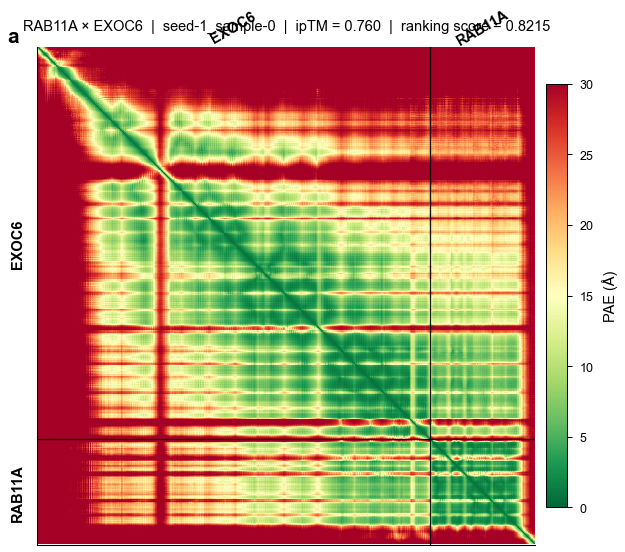

In [7]:
# ── Figure: best-ranked sample (large, single panel) ─────────────────────────
best = max(samples, key=lambda s: s["rank_score"] if not np.isnan(s["rank_score"]) else -1)
print(f"Best sample: {best['label']}  rank={best['rank_score']:.4f}")

pae = best["pae"]
tc  = best["tc"]
tc, pae = filter_ligand(tc, pae)
N   = len(tc)
bounds = chain_boundaries(tc)

fig, ax = plt.subplots(figsize=(NC1 * 1.3, NC1 * 1.3))

im = ax.imshow(
    pae, cmap="RdYlGn_r", vmin=0, vmax=30,
    aspect="equal", interpolation="nearest", rasterized=True,
)

# Chain boundaries
for b in bounds[1:-1]:
    ax.axhline(b - 0.5, color="k", linewidth=0.6, alpha=0.9)
    ax.axvline(b - 0.5, color="k", linewidth=0.6, alpha=0.9)

# Shaded inter-chain region highlight (F–I interface)
unique_chains = list(dict.fromkeys(tc))
offset = N * 0.04
for k, c in enumerate(unique_chains):
    mid  = (bounds[k] + bounds[k + 1]) / 2
    name = CHAIN_GENE.get(c, c)
    ax.text(mid, -offset, name,
            ha="center", va="center", fontsize=7,
            rotation=30, clip_on=False, fontweight="bold")
    ax.text(-offset, mid, name,
            ha="center", va="center", fontsize=7,
            rotation=90, clip_on=False, fontweight="bold")

ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_linewidth(0.5)

iptm_val = best["summary"].get("iptm", np.nan)
iptm_str = f"{iptm_val:.3f}" if not (isinstance(iptm_val, float) and np.isnan(iptm_val)) else "n/a"
ax.set_title(
    f"RAB11A × EXOC6  |  {best['label']}  |  ipTM = {iptm_str}  |  ranking score = {best['rank_score']:.4f}",
    pad=8, fontsize=7,
)

cb = fig.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
cb.set_label("PAE (Å)", fontsize=7)
cb.ax.tick_params(labelsize=6, width=0.5, length=2.5)
cb.outline.set_linewidth(0.5)

ax.text(-0.06, 1.04, "a", transform=ax.transAxes,
        fontsize=10, fontweight="bold", va="top")

save_fig(fig, "pae_heatmap_best_sample")
plt.show()

**Fig. 2 | PAE heatmap of the highest-ranked AlphaFold model for the RAB11A–EXOC6 complex.**
The PAE matrix is displayed for the sample with the highest AlphaFold ranking score among all predicted seeds and samples. Ligand chains are excluded; axes represent residues of EXOC6 (chain F) and RAB11A (chain I), labelled in bold. The solid line marks the chain boundary; the colour scale ranges from 0 to 30 Å (green–red). Low off-diagonal PAE values in the inter-chain quadrants indicate high confidence in the predicted relative orientation of the two proteins. The figure title reports the sample identifier, ipTM score, and ranking score.


In [9]:
# ── Summary table ─────────────────────────────────────────────────────────────
rows = []
for s in samples:
    summ = s["summary"]
    rows.append({
        "sample"       : s["label"],
        "ranking_score": round(s["rank_score"], 4) if not np.isnan(s["rank_score"]) else np.nan,
        "iptm"         : summ.get("iptm", np.nan),
        "ptm"          : summ.get("ptm", np.nan),
        "frac_disorder": summ.get("fraction_disordered", np.nan),
        "has_clash"    : summ.get("has_clash", np.nan),
    })

summary_df = (
    pd.DataFrame(rows)
    .sort_values("ranking_score", ascending=False)
    .reset_index(drop=True)
)
print(summary_df.to_string(index=False))

         sample  ranking_score  iptm  ptm  frac_disorder  has_clash
seed-1_sample-0         0.8215  0.76 0.66           0.17        0.0
seed-1_sample-4         0.8038  0.76 0.66           0.13        0.0
seed-1_sample-3         0.8036  0.75 0.66           0.13        0.0
seed-1_sample-1         0.7956  0.75 0.66           0.12        0.0
seed-1_sample-2         0.7891  0.75 0.66           0.11        0.0
